**K ближайших соседей** - алгоритм классификации, который классифицирует объект на основе k ближайших соседей в пространстве признаков. То есть объект относится к тому классу, который чаще всего встречается среди его ближайших соседей.

Как происходит классификация?
1. Выбирается число соседей k
2. Для нового объекта вычисляется расстояние до всех объектов обучающей выборки
3. Выбираются k ближайших
4. Класс определяется голосованием большинства
   
Чаще всего для определения расстояния используется Евклидово расстоние.

In [9]:
# Блок с используемыми библиотеками
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Блок с описанием и демонстрацией
df = pd.read_csv("../datasets/transactions_train.csv", sep=",")
df.head()

,transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,...,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
0,359131,2023-01-01 00:02:00.328105993,11102,2282,284,2,3,6091.747132,0.456269,2408.320473,...,desktop,0,0.142532,1,3,1,33.458018,2205.262235,0,0.099920
1,351207,2023-01-01 00:02:26.339769237,22891,3016,1363,2,3,3794.044563,0.449021,2765.255095,...,mobile,0,0.131811,0,5,0,3.375083,2638.786943,0,0.291715
2,10209,2023-01-01 00:06:54.145825305,3102,1855,1318,5,2,6697.058451,0.220252,1529.079168,...,desktop,0,0.322137,0,5,0,13.732603,1305.843886,0,0.216647
3,62660,2023-01-01 00:06:57.723185583,4041,2525,1914,1,1,2906.711704,0.202223,610.407487,...,mobile,0,0.171764,1,2,0,18.840187,513.517097,0,0.354154
4,384254,2023-01-01 00:08:05.487541188,3979,1555,360,2,3,5082.651983,0.171230,986.397163,...,mobile,0,0.248766,1,1,0,15.344375,816.975430,0,0.149084


In [10]:
# Блок с предварительной обработкой датасета

df.info()

# заменим время на категории день и ночь. Обычно день это 06:00 – 17:59, ночь: 18:00 – 05:59

df_dates = df.copy();
df_dates['transaction_time'] = pd.to_datetime(df['transaction_time'])

def is_night(t):
    hour = t.hour
    if 6 <= hour < 18:
        return False
    else:
        return True
        
df_dates['is_night'] = df_dates['transaction_time'].apply(is_night)

df_encoded = pd.get_dummies(df_dates, columns=['payment_channel', 'device_type'])

# заполнять нули тоже не нужно

df_transformed = df_encoded
df_transformed.info()

<class 'pandas.DataFrame'>
RangeIndex: 300113 entries, 0 to 300112
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   transaction_id                   300113 non-null  int64  
 1   transaction_time                 300113 non-null  str    
 2   customer_id                      300113 non-null  int64  
 3   merchant_id                      300113 non-null  int64  
 4   account_age_days                 300113 non-null  int64  
 5   credit_score_band                300113 non-null  int64  
 6   kyc_level                        300113 non-null  int64  
 7   avg_monthly_spend                300113 non-null  float64
 8   merchant_risk_score              300113 non-null  float64
 9   transaction_amount               300113 non-null  float64
 10  payment_channel                  300113 non-null  str    
 11  device_type                      300113 non-null  str    
 12  is_internatio

In [15]:
#Блок с обучением модели

# Признаки (X) и целевая переменная (y)

X = df_transformed.drop(['is_fraud', 'post_auth_risk_score', 'transaction_time'], axis=1)
y = df_transformed['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=6769
)

In [16]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [17]:
y_pred = model.predict(X_test)

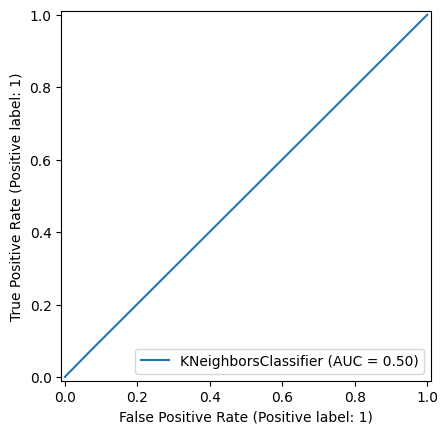

Accuracy: 0.9843226763074155
Precision: 0.9689887592406472
Recall: 0.9843226763074155
F1-score: 0.97659553049198
[[59082     3]
 [  938     0]]


In [18]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average='weighted', zero_division=0))

cm = confusion_matrix(y_test, y_pred)
print(cm)

Как видно, на сырых данных этот алгоритм очень плохо работает. Так как KNN использует расстояние, то необходимо данные нормализовать. 

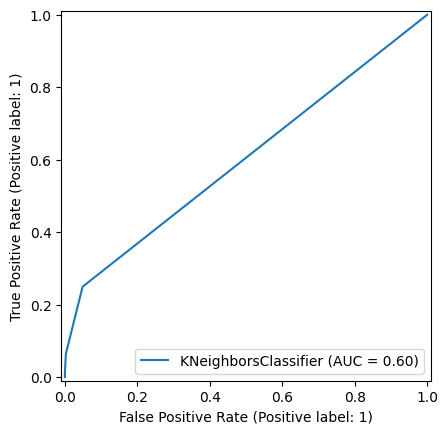

Accuracy: 0.9845059393899005
Precision: 0.9801532161533969
Recall: 0.9845059393899005
F1-score: 0.9771420945469577
[[59079     6]
 [  924    14]]


In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average='weighted', zero_division=0))

cm = confusion_matrix(y_test, y_pred)
print(cm)